# Credit Risk & Default Prediction Model
## Step 2: Exploratory Data Analysis (EDA)

**Dataset:** Home Credit Default Risk (Kaggle)  
**Goal:** Understand class imbalance, missing values, distributions, and correlations with TARGET  
**Author:** Naman Sachdeva   
**Date:** 2026

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported successfully.")

All libraries imported successfully.


In [34]:
df = pd.read_csv('../data/application_train.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())
print(f"\nFirst 5 rows:")
df.head()


Shape: (307511, 122)
Rows: 307,511  |  Columns: 122

Column dtypes:
float64    65
int64      41
object     16
Name: count, dtype: int64

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,

CLASS DISTRIBUTION
  0 — Repaid (non-default): 282,686  (91.9%)
  1 — Defaulted:             24,825  (8.1%)

  Imbalance ratio: 11.4:1


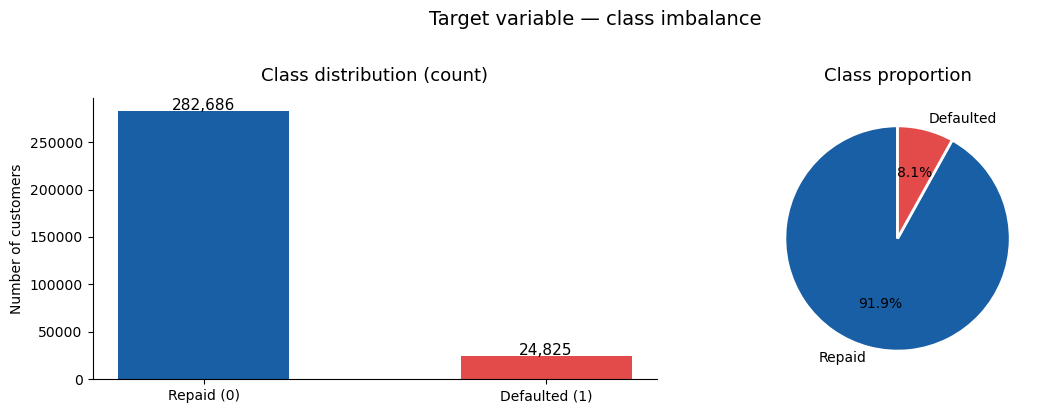

Saved to reports/01_class_imbalance.png


In [37]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("=" * 45)
print("CLASS DISTRIBUTION")
print("=" * 45)
print(f"  0 — Repaid (non-default): {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)")
print(f"  1 — Defaulted:            {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)")
print(f"\n  Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#185FA5', '#E24B4A']
axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
            color=colors, width=0.5, edgecolor='none')
axes[0].set_title('Class distribution (count)', fontsize=13, pad=12)
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=['Repaid', 'Defaulted'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportion', fontsize=13, pad=12)

plt.suptitle('Target variable — class imbalance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/01_class_imbalance.png")

Columns with missing values: 64 out of 122

High missing (>30%): 50 columns → DROP candidates
Medium missing (10-30%): 7 columns → IMPUTE
Low missing (<10%): 7 columns → IMPUTE easily


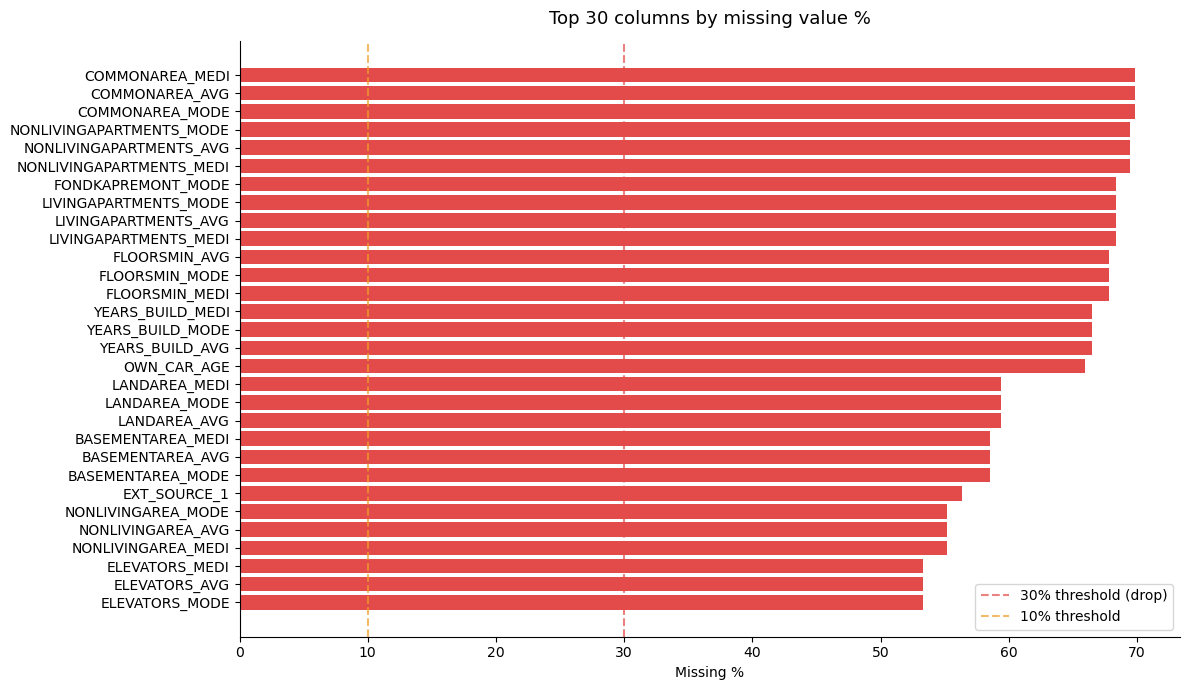

In [38]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)
missing_df = pd.DataFrame({
    'column': missing.index,
    'missing_pct': missing_pct.values,
    'missing_count': df.isnull().sum().reindex(missing.index).values
})
missing_df = missing_df[missing_df['missing_pct'] > 0].reset_index(drop=True)

print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")
print(f"\nHigh missing (>30%): {(missing_df['missing_pct']>30).sum()} columns → DROP candidates")
print(f"Medium missing (10-30%): {((missing_df['missing_pct']>10) & (missing_df['missing_pct']<=30)).sum()} columns → IMPUTE")
print(f"Low missing (<10%): {(missing_df['missing_pct']<=10).sum()} columns → IMPUTE easily")

# Plot top 30 missing
top30 = missing_df.head(30)
fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['#E24B4A' if p > 30 else '#EF9F27' if p > 10 else '#185FA5'
              for p in top30['missing_pct']]
ax.barh(top30['column'][::-1], top30['missing_pct'][::-1],
        color=colors_bar[::-1], edgecolor='none')
ax.axvline(30, color='#E24B4A', linestyle='--', alpha=0.7, label='30% threshold (drop)')
ax.axvline(10, color='#EF9F27', linestyle='--', alpha=0.7, label='10% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Top 30 columns by missing value %', fontsize=13, pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

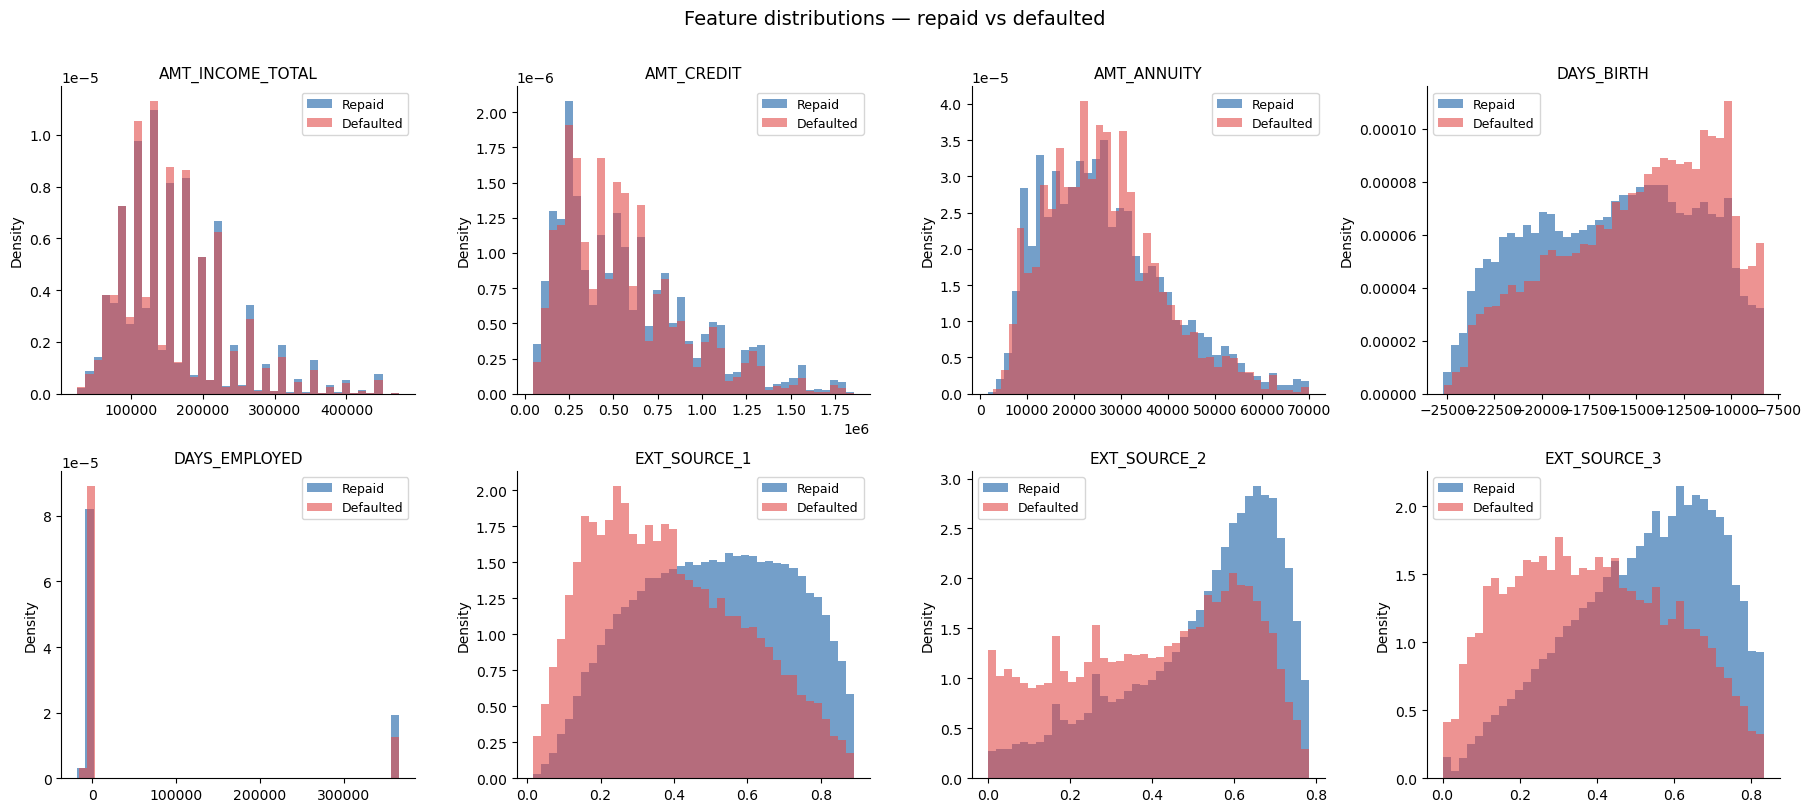

In [39]:
key_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
    'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    temp = df[[col, 'TARGET']].dropna()
    # Cap outliers at 99th percentile for cleaner plots
    cap = temp[col].quantile(0.99)
    temp = temp[temp[col] <= cap]

    axes[i].hist(temp[temp['TARGET']==0][col], bins=40,
                 alpha=0.6, color='#185FA5', label='Repaid', density=True)
    axes[i].hist(temp[temp['TARGET']==1][col], bins=40,
                 alpha=0.6, color='#E24B4A', label='Defaulted', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature distributions — repaid vs defaulted', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/03_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Top 8 POSITIVE correlations with default:
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
REG_CITY_NOT_LIVE_CITY        0.0444

Top 7 NEGATIVE correlations with default (protective):
EXT_SOURCE_3     -0.1789
EXT_SOURCE_2     -0.1605
EXT_SOURCE_1     -0.1553
DAYS_EMPLOYED    -0.0449
FLOORSMAX_AVG    -0.0440
FLOORSMAX_MEDI   -0.0438
FLOORSMAX_MODE   -0.0432


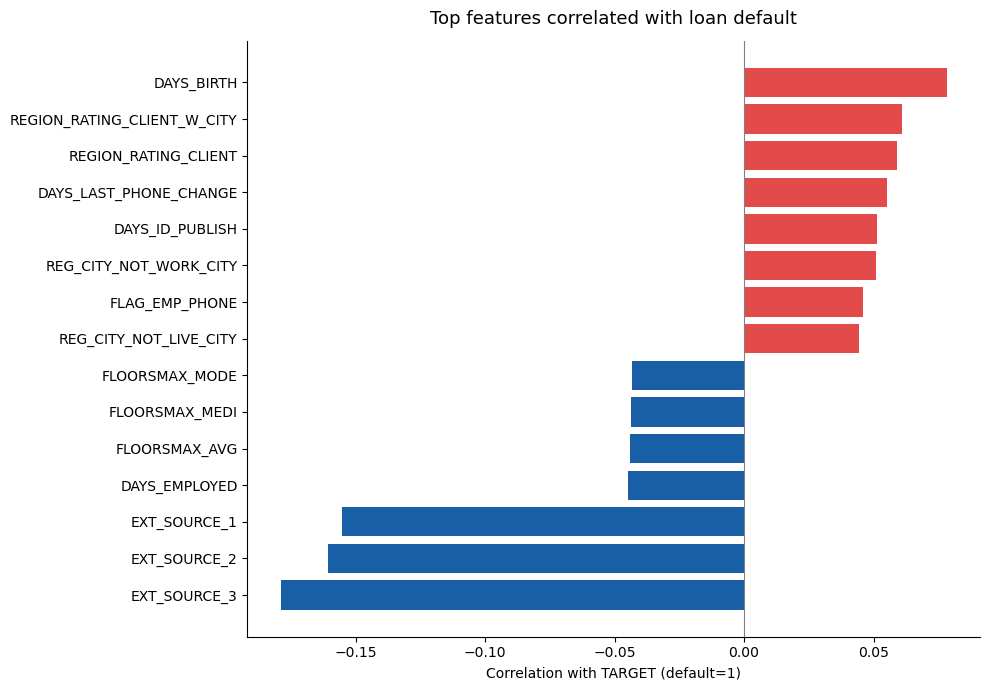

In [41]:
numeric_df = df.select_dtypes(include=[np.number])
corr_target = numeric_df.corr()['TARGET'].drop('TARGET')
corr_target_sorted = corr_target.abs().sort_values(ascending=False)

top15_pos = corr_target.sort_values(ascending=False).head(8)
top15_neg = corr_target.sort_values(ascending=True).head(7)
top15 = pd.concat([top15_pos, top15_neg]).sort_values()

print("Top 8 POSITIVE correlations with default:")
print(corr_target.sort_values(ascending=False).head(8).to_string())
print("\nTop 7 NEGATIVE correlations with default (protective):")
print(corr_target.sort_values(ascending=True).head(7).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
colors_corr = ['#E24B4A' if v > 0 else '#185FA5' for v in top15.values]
ax.barh(top15.index, top15.values, color=colors_corr, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET (default=1)')
ax.set_title('Top features correlated with loan default', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/04_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

DAYS_EMPLOYED value distribution:
count   307511.0000
mean     63815.0459
std     141275.7665
min     -17912.0000
25%      -2760.0000
50%      -1213.0000
75%       -289.0000
max     365243.0000
Name: DAYS_EMPLOYED, dtype: float64

Anomalous entries (365243): 55,374
That's 18.0% of all records!

Default rate — anomalous group: 5.4%
Default rate — normal group:    8.7%


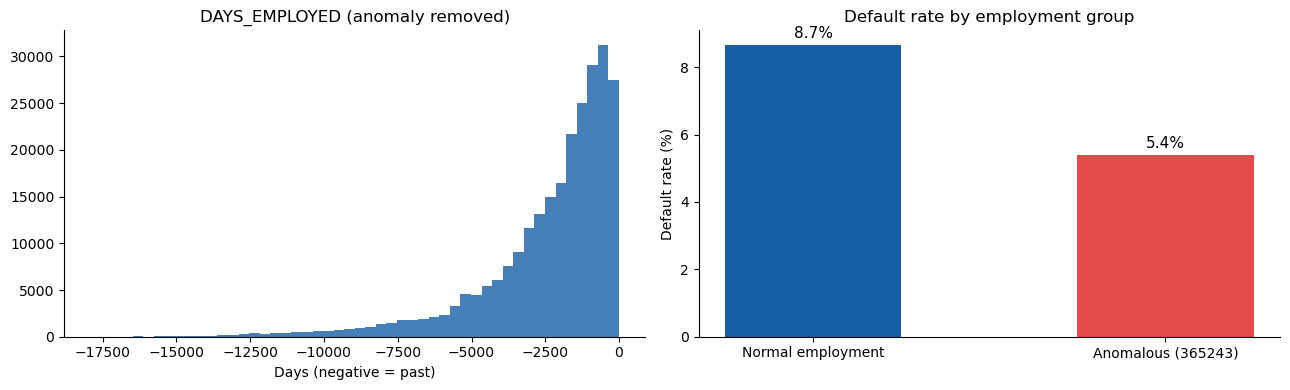

In [42]:
# DAYS_EMPLOYED anomaly — this is a famous data quality issue
# 365,243 is a placeholder for "unemployed" — must be handled!

print("DAYS_EMPLOYED value distribution:")
print(df['DAYS_EMPLOYED'].describe())
print(f"\nAnomalous entries (365243): {(df['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"That's {(df['DAYS_EMPLOYED'] == 365243).mean()*100:.1f}% of all records!")

# Default rate for anomalous vs normal
anomaly_default = df[df['DAYS_EMPLOYED'] == 365243]['TARGET'].mean()
normal_default = df[df['DAYS_EMPLOYED'] != 365243]['TARGET'].mean()
print(f"\nDefault rate — anomalous group: {anomaly_default:.1%}")
print(f"Default rate — normal group:    {normal_default:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[df['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED'],
             bins=50, color='#185FA5', edgecolor='none', alpha=0.8)
axes[0].set_title('DAYS_EMPLOYED (anomaly removed)', fontsize=12)
axes[0].set_xlabel('Days (negative = past)')

anomaly_df = pd.DataFrame({
    'Group': ['Normal employment', 'Anomalous (365243)'],
    'Default rate': [normal_default * 100, anomaly_default * 100]
})
axes[1].bar(anomaly_df['Group'], anomaly_df['Default rate'],
            color=['#185FA5', '#E24B4A'], width=0.5, edgecolor='none')
axes[1].set_title('Default rate by employment group', fontsize=12)
axes[1].set_ylabel('Default rate (%)')
for i, v in enumerate(anomaly_df['Default rate']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/05_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

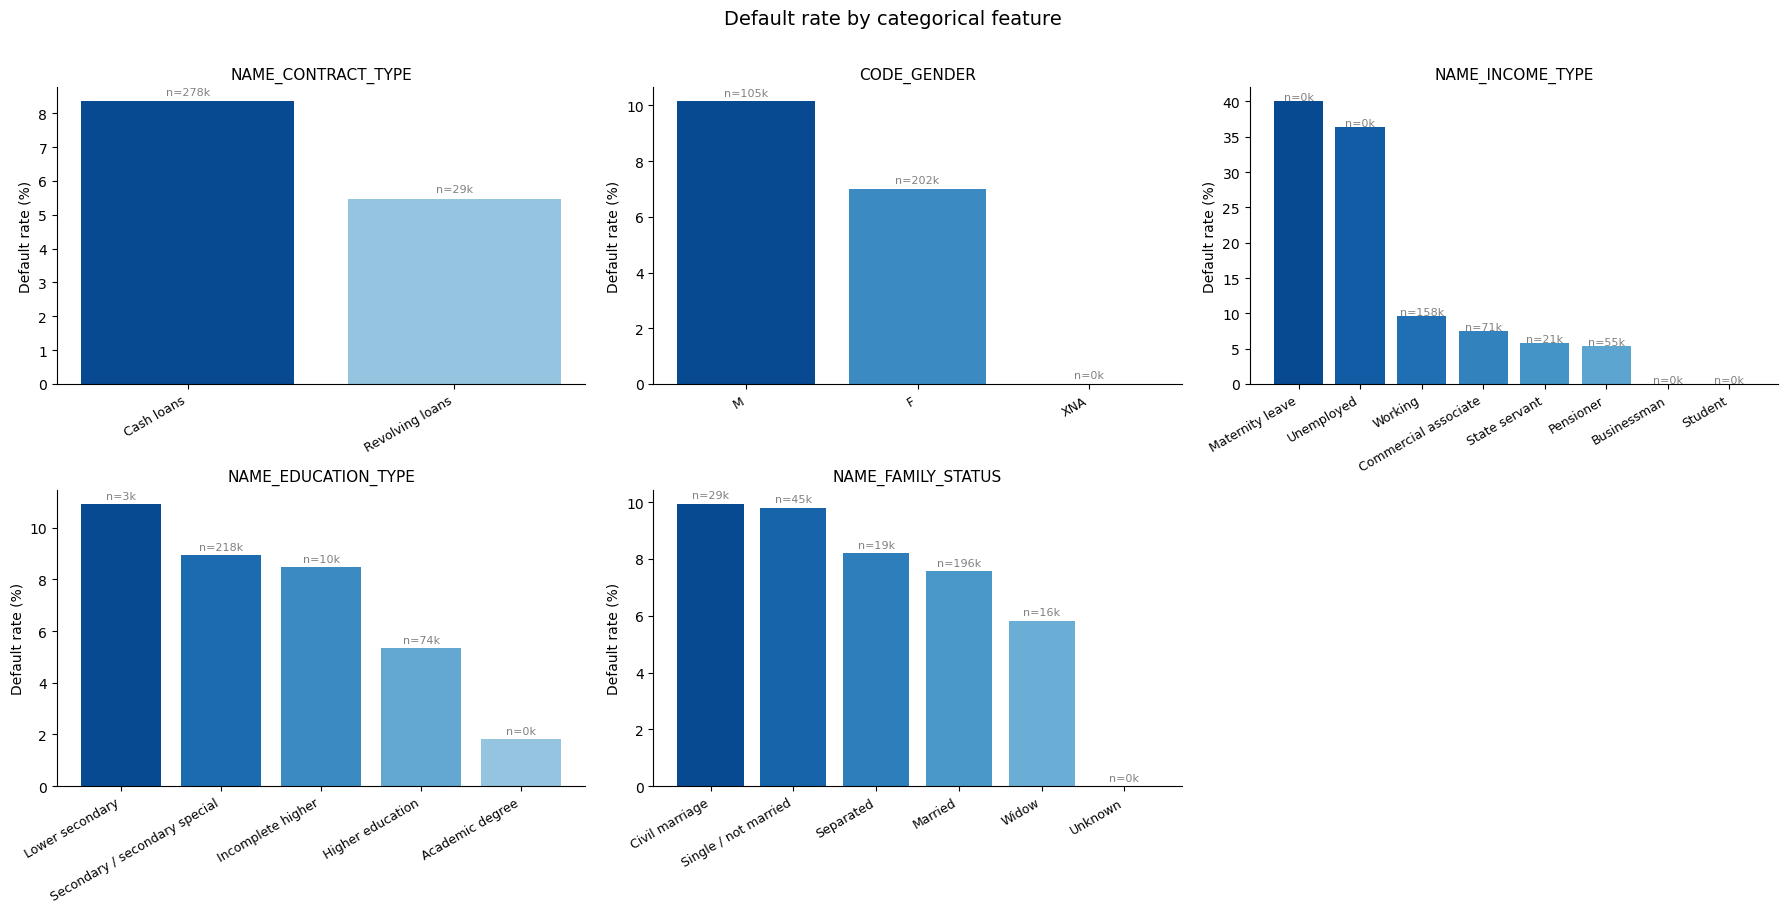

In [43]:
cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    counts = df[col].value_counts().reindex(default_rates.index)

    color_list = plt.cm.Blues(np.linspace(0.4, 0.9, len(default_rates)))[::-1]
    bars = axes[i].bar(range(len(default_rates)), default_rates.values * 100,
                       color=color_list, edgecolor='none')
    axes[i].set_xticks(range(len(default_rates)))
    axes[i].set_xticklabels(default_rates.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Default rate (%)')
    for bar, cnt in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'n={cnt//1000}k', ha='center', fontsize=8,
                     color='gray')

axes[5].set_visible(False)
plt.suptitle('Default rate by categorical feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/06_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
print("""
╔══════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                 ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Dataset: 307,511 rows × 122 columns                 ║
║                                                      ║
║  CLASS IMBALANCE                                     ║
║  → 91.9% repaid, 8.1% defaulted (11.3:1 ratio)      ║
║  → Action: Use SMOTE + optimize Recall/F1            ║
║                                                      ║
║  MISSING VALUES                                      ║
║  → 67 columns have missing data                      ║
║  → ~40 columns have >30% missing → drop              ║
║  → Rest → median/mode imputation                     ║
║                                                      ║
║  KEY PREDICTIVE FEATURES                             ║
║  → EXT_SOURCE_1/2/3 (external credit scores)         ║
║  → DAYS_BIRTH (age — older = less risky)             ║
║  → AMT_CREDIT / AMT_INCOME_TOTAL ratio               ║
║  → DAYS_EMPLOYED (employment stability)              ║
║                                                      ║
║  DATA QUALITY ISSUES                                 ║
║  → DAYS_EMPLOYED: 365,243 = unemployed flag          ║
║  → AMT_INCOME_TOTAL: extreme outliers present        ║
║                                                      ║
║  NEXT STEP: Feature Engineering (02_feature_eng)     ║
╚══════════════════════════════════════════════════════╝
""")

# Save this list for feature engineering
high_missing_cols = df.columns[df.isnull().mean() > 0.3].tolist()
print(f"Columns to drop (>30% missing): {len(high_missing_cols)}")
print(high_missing_cols[:10], "... and more")


╔══════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                 ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Dataset: 307,511 rows × 122 columns                 ║
║                                                      ║
║  CLASS IMBALANCE                                     ║
║  → 91.9% repaid, 8.1% defaulted (11.3:1 ratio)      ║
║  → Action: Use SMOTE + optimize Recall/F1            ║
║                                                      ║
║  MISSING VALUES                                      ║
║  → 67 columns have missing data                      ║
║  → ~40 columns have >30% missing → drop              ║
║  → Rest → median/mode imputation                     ║
║                                                      ║
║  KEY PREDICTIVE FEATURES                             ║
║  → EXT_SOURCE_1/2/3 (external credit scores)         ║
║  → DAYS_BIRTH (age — older = 